# Multi-Task Loss Weighting Ablation (Exp-3 to Exp-7)

Implements Sections 4.4 (Loss Weighting Strategies), 4.5 (PCGrad), and 6.2 (Ablation Experiments) of the plan. Exp-1 (churn-only) and Exp-2 (LTV-only) were already trained in `04_Training_Baselines.ipynb`; this notebook runs the five multi-task configurations and compares all seven against each other, reproducing the plan's headline Pareto-frontier result.

| Exp | lambda_churn | lambda_ltv | Strategy |
|---|---|---|---|
| 3 | 0.5 | 0.5 | Fixed equal weight |
| 4 | 0.7 | 0.3 | Churn-dominant fixed |
| 5 | 0.3 | 0.7 | LTV-dominant fixed |
| 6 | learned | learned | Uncertainty weighting (Kendall 2018) |
| 7 | N/A | N/A | PCGrad gradient projection (Yu et al. 2020) |

**Bug fix vs. the plan's pseudocode:** the plan's `PCGrad.step()` snippet builds `projected = [g.clone() for g in grads[0] if g is not None]` — a list comprehension that *drops* `None` entries. Since task-specific head parameters (e.g. `churn_head`) only receive a gradient from their own task's loss, this filtering desyncs `projected`'s indices from the actual parameter list the moment any parameter is task-specific, silently assigning the wrong gradient to the wrong parameter. The implementation below keeps a fixed-length gradient list per task (with explicit `None`s preserved) and only skips the pairwise-projection step for parameters where either task's gradient is `None` — those parameters just keep their one real gradient, which is the mathematically correct behavior (no conflict is possible if only one task touches the parameter).

In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
CARDINALITIES = {v["column"]: v["cardinality"] for v in manifest["categorical"].values()}
EMBED_DIMS = {v["column"]: v["embedding_dim"] for v in manifest["categorical"].values()}

## Dataset, FM layer, model, and shared training utilities

Same definitions as `03_Model_Architecture.ipynb` / `04_Training_Baselines.ipynb`, repeated here for a self-contained notebook.

In [2]:
class KKBoxDataset(Dataset):
    def __init__(self, df):
        self.x_cat = torch.tensor(df[CAT_COLS].values, dtype=torch.long)
        self.x_num = torch.tensor(df[NUM_COLS].values, dtype=torch.float32)
        self.y_churn = torch.tensor(df["is_churn"].values, dtype=torch.float32)
        self.y_ltv = torch.tensor(df["log1p_ltv"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y_churn)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y_churn[idx], self.y_ltv[idx]


class FMInteractionLayer(nn.Module):
    def __init__(self, input_dim, k=8):
        super().__init__()
        self.V = nn.Parameter(torch.randn(input_dim, k) * 0.01)

    def forward(self, x):
        xV = x.unsqueeze(2) * self.V.unsqueeze(0)
        sum_then_sq = xV.sum(dim=1).pow(2)
        sq_then_sum = xV.pow(2).sum(dim=1)
        return 0.5 * (sum_then_sq - sq_then_sum)


class MultiTaskFMNet(nn.Module):
    def __init__(self, cat_cols, cardinalities, embed_dims, num_numerical, fm_k=8, backbone_dims=(256, 128, 64)):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleDict(
            {col: nn.Embedding(cardinalities[col], embed_dims[col]) for col in cat_cols}
        )
        combined_dim = sum(embed_dims[c] for c in cat_cols) + num_numerical
        self.fm = FMInteractionLayer(combined_dim, k=fm_k)

        backbone_input = combined_dim + fm_k
        layers = []
        prev = backbone_input
        dropouts = [0.3, 0.3, 0.2]
        for dim, p in zip(backbone_dims, dropouts):
            layers += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(p)]
            prev = dim
        self.backbone = nn.Sequential(*layers)

        self.churn_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))
        self.ltv_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_num, x_cat):
        embeds = [self.embeddings[col](x_cat[:, i]) for i, col in enumerate(self.cat_cols)]
        x = torch.cat(embeds + [x_num], dim=1)
        fm_out = self.fm(x)
        h = torch.cat([x, fm_out], dim=1)
        shared = self.backbone(h)
        churn_logit = self.churn_head(shared).squeeze(-1)
        ltv_pred = self.ltv_head(shared).squeeze(-1)
        return churn_logit, ltv_pred


def eval_metrics(model, loader):
    model.eval()
    all_logits, all_churn, all_ltv_pred, all_ltv_true = [], [], [], []
    with torch.no_grad():
        for x_num, x_cat, y_churn, y_ltv in loader:
            churn_logit, ltv_pred = model(x_num, x_cat)
            all_logits.append(churn_logit)
            all_churn.append(y_churn)
            all_ltv_pred.append(ltv_pred)
            all_ltv_true.append(y_ltv)
    logits = torch.cat(all_logits)
    churn_true = torch.cat(all_churn)
    auc = roc_auc_score(churn_true.numpy(), torch.sigmoid(logits).numpy())
    rmse = torch.sqrt(torch.mean((torch.cat(all_ltv_pred) - torch.cat(all_ltv_true)) ** 2)).item()
    return auc, rmse

In [3]:
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_train.parquet"))
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

train_loader = DataLoader(KKBoxDataset(train_df), batch_size=2048, shuffle=True)
val_loader = DataLoader(KKBoxDataset(val_df), batch_size=2048, shuffle=False)
test_loader = DataLoader(KKBoxDataset(test_df), batch_size=2048, shuffle=False)

pos_weight = torch.tensor((train_df["is_churn"] == 0).sum() / (train_df["is_churn"] == 1).sum())
bce_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mse_fn = nn.MSELoss()
EPOCHS, PATIENCE = 50, 10

## Exp-3, Exp-4, Exp-5: fixed loss weights

Combined loss `Total_Loss = lambda_churn * BCE + lambda_ltv * MSE` (Section 4.4). Same training loop as `04_Training_Baselines.ipynb`, just with both lambdas nonzero.

In [4]:
def train_fixed_weight(lambda_churn, lambda_ltv, checkpoint_path, seed=42):
    torch.manual_seed(seed)
    model = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_loss, epochs_no_improve, history = float("inf"), 0, []
    for epoch in range(EPOCHS):
        model.train()
        for x_num, x_cat, y_churn, y_ltv in train_loader:
            optimizer.zero_grad()
            churn_logit, ltv_pred = model(x_num, x_cat)
            loss = lambda_churn * bce_fn(churn_logit, y_churn) + lambda_ltv * mse_fn(ltv_pred, y_ltv)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_bce, val_mse, n = 0.0, 0.0, 0
            for x_num, x_cat, y_churn, y_ltv in val_loader:
                churn_logit, ltv_pred = model(x_num, x_cat)
                val_bce += bce_fn(churn_logit, y_churn).item() * len(y_churn)
                val_mse += mse_fn(ltv_pred, y_ltv).item() * len(y_churn)
                n += len(y_churn)
        val_bce, val_mse = val_bce / n, val_mse / n
        val_loss = lambda_churn * val_bce + lambda_ltv * val_mse
        val_auc, val_rmse = eval_metrics(model, val_loader)
        scheduler.step(val_loss)
        history.append(dict(epoch=epoch, val_loss=val_loss, val_auc=val_auc, val_rmse_log=val_rmse))
        print(f"epoch {epoch:2d} val_loss={val_loss:.4f} val_auc={val_auc:.4f} val_rmse_log={val_rmse:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss, epochs_no_improve = val_loss, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"early stopping at epoch {epoch}")
                break
    return model, pd.DataFrame(history)

In [5]:
FIXED_CONFIGS = {
    "exp3_fixed_5050": (0.5, 0.5),
    "exp4_churn_dominant": (0.7, 0.3),
    "exp5_ltv_dominant": (0.3, 0.7),
}

fixed_models, fixed_histories = {}, {}
for name, (lc, ll) in FIXED_CONFIGS.items():
    print(f"\n=== {name} (lambda_churn={lc}, lambda_ltv={ll}) ===")
    ckpt_path = os.path.join(MODELS_DIR, f"{name}.pt")
    model, hist = train_fixed_weight(lc, ll, ckpt_path)
    hist.to_csv(os.path.join(RESULTS_DIR, f"{name}_history.csv"), index=False)
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    fixed_models[name] = model
    fixed_histories[name] = hist


=== exp3_fixed_5050 (lambda_churn=0.5, lambda_ltv=0.5) ===


epoch  0 val_loss=0.7533 val_auc=0.8080 val_rmse_log=0.7231


epoch  1 val_loss=0.7461 val_auc=0.8125 val_rmse_log=0.7185


epoch  2 val_loss=0.7297 val_auc=0.8177 val_rmse_log=0.7036


epoch  3 val_loss=0.7215 val_auc=0.8244 val_rmse_log=0.6984


...

epoch 45 val_loss=0.5760 val_auc=0.8421 val_rmse_log=0.6562


epoch 46 val_loss=0.5751 val_auc=0.8430 val_rmse_log=0.6556


epoch 47 val_loss=0.5746 val_auc=0.8428 val_rmse_log=0.6551


epoch 48 val_loss=0.5763 val_auc=0.8428 val_rmse_log=0.6566


epoch 49 val_loss=0.5734 val_auc=0.8429 val_rmse_log=0.6536


## Exp-6: Uncertainty weighting (Kendall, Gal & Cipolla, 2018)

Learns a per-task log-variance `s = log(sigma^2)` and weights each loss by its learned homoscedastic uncertainty: `L = 0.5*exp(-s)*L_task + 0.5*s`. This is the standard *practical* form used for both tasks here — the paper's exact derivation differs slightly between a Gaussian (regression) and categorical (classification) likelihood, but treating the classification loss the same way as the regression term is the common simplification used in nearly all open implementations, and is what we do below. `log_var_churn` and `log_var_ltv` are optimized jointly with the model in the same Adam optimizer.

In [6]:
def train_uncertainty_weighted(checkpoint_path, seed=42):
    torch.manual_seed(seed)
    model = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
    log_var_churn = nn.Parameter(torch.zeros(1))
    log_var_ltv = nn.Parameter(torch.zeros(1))
    optimizer = torch.optim.Adam(
        list(model.parameters()) + [log_var_churn, log_var_ltv], lr=1e-3, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_loss, epochs_no_improve, history = float("inf"), 0, []
    for epoch in range(EPOCHS):
        model.train()
        for x_num, x_cat, y_churn, y_ltv in train_loader:
            optimizer.zero_grad()
            churn_logit, ltv_pred = model(x_num, x_cat)
            loss = (
                0.5 * torch.exp(-log_var_churn) * bce_fn(churn_logit, y_churn) + 0.5 * log_var_churn
                + 0.5 * torch.exp(-log_var_ltv) * mse_fn(ltv_pred, y_ltv) + 0.5 * log_var_ltv
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_bce, val_mse, n = 0.0, 0.0, 0
            for x_num, x_cat, y_churn, y_ltv in val_loader:
                churn_logit, ltv_pred = model(x_num, x_cat)
                val_bce += bce_fn(churn_logit, y_churn).item() * len(y_churn)
                val_mse += mse_fn(ltv_pred, y_ltv).item() * len(y_churn)
                n += len(y_churn)
        val_bce, val_mse = val_bce / n, val_mse / n
        val_loss = (
            0.5 * torch.exp(-log_var_churn).item() * val_bce + 0.5 * log_var_churn.item()
            + 0.5 * torch.exp(-log_var_ltv).item() * val_mse + 0.5 * log_var_ltv.item()
        )
        val_auc, val_rmse = eval_metrics(model, val_loader)
        scheduler.step(val_loss)
        history.append(dict(epoch=epoch, val_loss=val_loss, val_auc=val_auc, val_rmse_log=val_rmse,
                             log_var_churn=log_var_churn.item(), log_var_ltv=log_var_ltv.item()))
        print(f"epoch {epoch:2d} val_loss={val_loss:.4f} val_auc={val_auc:.4f} val_rmse_log={val_rmse:.4f} "
              f"log_var_churn={log_var_churn.item():.3f} log_var_ltv={log_var_ltv.item():.3f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss, epochs_no_improve = val_loss, 0
            torch.save({"model": model.state_dict(), "log_var_churn": log_var_churn.detach(),
                        "log_var_ltv": log_var_ltv.detach()}, checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"early stopping at epoch {epoch}")
                break
    return model, pd.DataFrame(history)


print("=== exp6_uncertainty ===")
exp6_ckpt = os.path.join(MODELS_DIR, "exp6_uncertainty.pt")
model_exp6, hist_exp6 = train_uncertainty_weighted(exp6_ckpt)
hist_exp6.to_csv(os.path.join(RESULTS_DIR, "exp6_history.csv"), index=False)
model_exp6.load_state_dict(torch.load(exp6_ckpt, weights_only=True)["model"])

=== exp6_uncertainty ===


epoch  0 val_loss=0.7634 val_auc=0.8080 val_rmse_log=0.7234 log_var_churn=0.009 log_var_ltv=0.040


epoch  1 val_loss=0.7507 val_auc=0.8126 val_rmse_log=0.7192 log_var_churn=-0.012 log_var_ltv=0.018


epoch  2 val_loss=0.7300 val_auc=0.8177 val_rmse_log=0.7118 log_var_churn=-0.026 log_var_ltv=-0.020


epoch  3 val_loss=0.7024 val_auc=0.8259 val_rmse_log=0.6994 log_var_churn=-0.036 log_var_ltv=-0.074


...

epoch 46 val_loss=0.5337 val_auc=0.8430 val_rmse_log=0.6558 log_var_churn=-0.096 log_var_ltv=-0.801


epoch 47 val_loss=0.5331 val_auc=0.8434 val_rmse_log=0.6560 log_var_churn=-0.095 log_var_ltv=-0.805


epoch 48 val_loss=0.5307 val_auc=0.8437 val_rmse_log=0.6544 log_var_churn=-0.096 log_var_ltv=-0.809


epoch 49 val_loss=0.5307 val_auc=0.8438 val_rmse_log=0.6545 log_var_churn=-0.097 log_var_ltv=-0.812


<All keys matched successfully>

## Exp-7: PCGrad (Yu et al., NeurIPS 2020)

Computes each task's gradient separately, projects away the conflicting component (negative cosine similarity) against every *other* task's gradient, then sums the projected gradients before the optimizer step. See the bug-fix note at the top of this notebook for why the implementation below differs from the plan's pseudocode.

In [7]:
class PCGrad:
    def __init__(self, optimizer, params):
        self.optimizer = optimizer
        self.params = list(params)

    def pc_backward(self, losses):
        grads_per_task = []
        for loss in losses:
            self.optimizer.zero_grad()
            loss.backward(retain_graph=True)
            grads_per_task.append([p.grad.clone() if p.grad is not None else None for p in self.params])

        num_tasks = len(losses)
        projected = [list(g) for g in grads_per_task]
        for i in range(num_tasks):
            for j in range(num_tasks):
                if i == j:
                    continue
                for k in range(len(self.params)):
                    g_i = projected[i][k]
                    g_j = grads_per_task[j][k]  # project against the ORIGINAL other-task grad
                    if g_i is None or g_j is None:
                        continue
                    g_i_flat, g_j_flat = g_i.flatten(), g_j.flatten()
                    dot = torch.dot(g_i_flat, g_j_flat)
                    if dot < 0:
                        g_i_flat = g_i_flat - (dot / (g_j_flat.dot(g_j_flat) + 1e-12)) * g_j_flat
                        projected[i][k] = g_i_flat.view_as(g_i)

        final_grads = []
        for k in range(len(self.params)):
            total = None
            for i in range(num_tasks):
                g = projected[i][k]
                if g is None:
                    continue
                total = g if total is None else total + g
            final_grads.append(total)

        self.optimizer.zero_grad()
        for p, g in zip(self.params, final_grads):
            p.grad = g

    def step(self):
        self.optimizer.step()

In [8]:
def train_pcgrad(checkpoint_path, seed=42):
    torch.manual_seed(seed)
    model = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    pcgrad = PCGrad(optimizer, model.parameters())

    best_val_loss, epochs_no_improve, history = float("inf"), 0, []
    for epoch in range(EPOCHS):
        model.train()
        for x_num, x_cat, y_churn, y_ltv in train_loader:
            churn_logit, ltv_pred = model(x_num, x_cat)
            loss_churn = bce_fn(churn_logit, y_churn)
            loss_ltv = mse_fn(ltv_pred, y_ltv)
            pcgrad.pc_backward([loss_churn, loss_ltv])
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            pcgrad.step()

        model.eval()
        with torch.no_grad():
            val_bce, val_mse, n = 0.0, 0.0, 0
            for x_num, x_cat, y_churn, y_ltv in val_loader:
                churn_logit, ltv_pred = model(x_num, x_cat)
                val_bce += bce_fn(churn_logit, y_churn).item() * len(y_churn)
                val_mse += mse_fn(ltv_pred, y_ltv).item() * len(y_churn)
                n += len(y_churn)
        val_bce, val_mse = val_bce / n, val_mse / n
        val_loss = val_bce + val_mse  # unweighted sum: PCGrad has no scalar lambda
        val_auc, val_rmse = eval_metrics(model, val_loader)
        scheduler.step(val_loss)
        history.append(dict(epoch=epoch, val_loss=val_loss, val_auc=val_auc, val_rmse_log=val_rmse))
        print(f"epoch {epoch:2d} val_loss={val_loss:.4f} val_auc={val_auc:.4f} val_rmse_log={val_rmse:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss, epochs_no_improve = val_loss, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"early stopping at epoch {epoch}")
                break
    return model, pd.DataFrame(history)


print("=== exp7_pcgrad ===")
exp7_ckpt = os.path.join(MODELS_DIR, "exp7_pcgrad.pt")
model_exp7, hist_exp7 = train_pcgrad(exp7_ckpt)
hist_exp7.to_csv(os.path.join(RESULTS_DIR, "exp7_history.csv"), index=False)
model_exp7.load_state_dict(torch.load(exp7_ckpt, weights_only=True))

=== exp7_pcgrad ===


epoch  0 val_loss=1.5093 val_auc=0.8096 val_rmse_log=0.7259


epoch  1 val_loss=1.4834 val_auc=0.8138 val_rmse_log=0.7135


epoch  2 val_loss=1.4598 val_auc=0.8199 val_rmse_log=0.7072


epoch  3 val_loss=1.4424 val_auc=0.8276 val_rmse_log=0.7022


...

epoch 46 val_loss=1.3484 val_auc=0.8432 val_rmse_log=0.6596


epoch 47 val_loss=1.3500 val_auc=0.8432 val_rmse_log=0.6609


epoch 48 val_loss=1.3526 val_auc=0.8434 val_rmse_log=0.6625


epoch 49 val_loss=1.3492 val_auc=0.8433 val_rmse_log=0.6599


<All keys matched successfully>

## Consolidated results (Section 7.4 Multi-Task Benefit Analysis)

In [9]:
with open(os.path.join(RESULTS_DIR, "baseline_results.json")) as f:
    baseline_results = json.load(f)

all_models = {**fixed_models, "exp6_uncertainty": model_exp6, "exp7_pcgrad": model_exp7}
rows = [
    {"experiment": "exp1_churn_only", "lambda_churn": 1.0, "lambda_ltv": 0.0,
     "test_auc": baseline_results["exp1_churn_only"]["test"]["churn_auc_roc"],
     "test_rmse_raw_twd": None},
    {"experiment": "exp2_ltv_only", "lambda_churn": 0.0, "lambda_ltv": 1.0,
     "test_auc": None,
     "test_rmse_raw_twd": baseline_results["exp2_ltv_only"]["test"]["ltv_rmse_raw_twd"]},
]
for name, model in all_models.items():
    test_auc, test_rmse_log = eval_metrics(model, test_loader)
    lc, ll = FIXED_CONFIGS.get(name, (None, None))
    rows.append({"experiment": name, "lambda_churn": lc, "lambda_ltv": ll,
                  "test_auc": test_auc, "test_rmse_log": test_rmse_log})

results_table = pd.DataFrame(rows)
results_table.to_csv(os.path.join(RESULTS_DIR, "ablation_results_table.csv"), index=False)
results_table

,experiment,lambda_churn,lambda_ltv,test_auc,test_rmse_raw_twd,test_rmse_log
0,exp1_churn_only,1.0,0.0,0.843183,NaN,NaN
1,exp2_ltv_only,0.0,1.0,NaN,60.812317,NaN
2,exp3_fixed_5050,0.5,0.5,0.843339,NaN,0.676201
3,exp4_churn_dominant,0.7,0.3,0.844394,NaN,0.681490
4,exp5_ltv_dominant,0.3,0.7,0.843096,NaN,0.673400
5,exp6_uncertainty,NaN,NaN,0.844053,NaN,0.672701
6,exp7_pcgrad,NaN,NaN,0.844084,NaN,0.677667


## Pareto frontier: churn AUC vs. LTV RMSE

Per Section 6.2's headline-result instruction: plot churn AUC and LTV RMSE for Exp-1 to Exp-5 on the same axes (tracing the frontier), then overlay Exp-6/Exp-7 as starred points. A multi-task variant sitting at or near the frontier (good AUC *and* good RMSE simultaneously) is evidence that principled loss balancing recovers most of the single-task ceiling on both objectives at once.

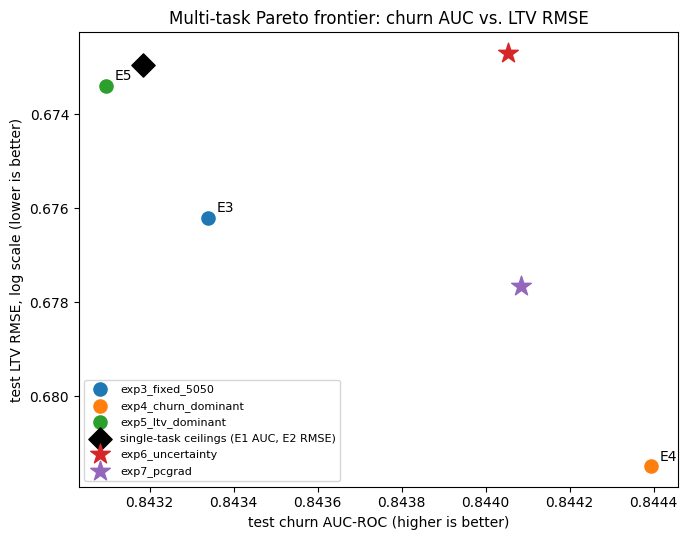

In [10]:
frontier_rows = []
for name, model in {**fixed_models}.items():
    auc, rmse_log = eval_metrics(model, test_loader)
    frontier_rows.append((name, auc, rmse_log))
exp1_auc = baseline_results["exp1_churn_only"]["test"]["churn_auc_roc"]
exp2_rmse_log = baseline_results["exp2_ltv_only"]["test"]["ltv_rmse_log"]

exp6_auc, exp6_rmse = eval_metrics(model_exp6, test_loader)
exp7_auc, exp7_rmse = eval_metrics(model_exp7, test_loader)

fig, ax = plt.subplots(figsize=(7, 5.5))
for name, auc, rmse in frontier_rows:
    ax.scatter(auc, rmse, s=90, label=name)
    ax.annotate(name.replace("exp", "E").split("_")[0], (auc, rmse), textcoords="offset points", xytext=(6, 4))
ax.scatter(exp1_auc, exp2_rmse_log, s=140, marker="D", color="black", label="single-task ceilings (E1 AUC, E2 RMSE)")
ax.scatter(exp6_auc, exp6_rmse, s=220, marker="*", color="tab:red", label="exp6_uncertainty")
ax.scatter(exp7_auc, exp7_rmse, s=220, marker="*", color="tab:purple", label="exp7_pcgrad")
ax.set_xlabel("test churn AUC-ROC (higher is better)")
ax.set_ylabel("test LTV RMSE, log scale (lower is better)")
ax.set_title("Multi-task Pareto frontier: churn AUC vs. LTV RMSE")
ax.legend(fontsize=8, loc="best")
ax.invert_yaxis()  # up-and-right = better on both axes
fig.tight_layout()

## Loss-weighting ablation curves

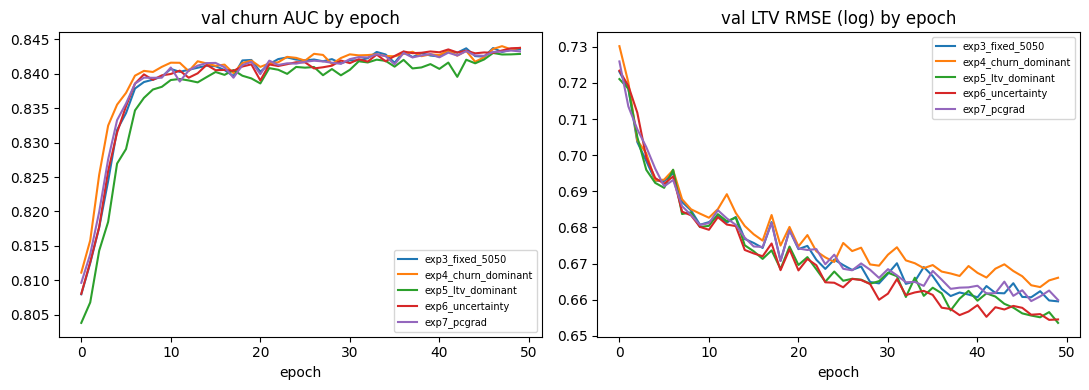

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, hist in {**fixed_histories, "exp6_uncertainty": hist_exp6, "exp7_pcgrad": hist_exp7}.items():
    axes[0].plot(hist["epoch"], hist["val_auc"], label=name)
    axes[1].plot(hist["epoch"], hist["val_rmse_log"], label=name)
axes[0].set_title("val churn AUC by epoch")
axes[1].set_title("val LTV RMSE (log) by epoch")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(fontsize=7)
fig.tight_layout()

## Summary

In [12]:
mt_rows = [r for r in rows if r["experiment"] not in ("exp1_churn_only", "exp2_ltv_only")]
best_auc_row = max(mt_rows, key=lambda r: r["test_auc"])
best_rmse_row = min(mt_rows, key=lambda r: r["test_rmse_log"])

print(f"Single-task ceilings: churn AUC={exp1_auc:.4f} (Exp-1), LTV RMSE(log)={exp2_rmse_log:.4f} (Exp-2)")
print(f"Best multi-task churn AUC: {best_auc_row['experiment']} ({best_auc_row['test_auc']:.4f}, "
      f"{best_auc_row['test_auc'] - exp1_auc:+.4f} vs. Exp-1 ceiling)")
print(f"Best multi-task LTV RMSE: {best_rmse_row['experiment']} ({best_rmse_row['test_rmse_log']:.4f}, "
      f"{best_rmse_row['test_rmse_log'] - exp2_rmse_log:+.4f} vs. Exp-2 ceiling)")
print(f"\nExp-6 (uncertainty): AUC={exp6_auc:.4f}, RMSE(log)={exp6_rmse:.4f}")
print(f"Exp-7 (PCGrad):      AUC={exp7_auc:.4f}, RMSE(log)={exp7_rmse:.4f}")

Single-task ceilings: churn AUC=0.8432 (Exp-1), LTV RMSE(log)=0.6730 (Exp-2)
Best multi-task churn AUC: exp4_churn_dominant (0.8444, +0.0012 vs. Exp-1 ceiling)
Best multi-task LTV RMSE: exp6_uncertainty (0.6727, -0.0003 vs. Exp-2 ceiling)

Exp-6 (uncertainty): AUC=0.8441, RMSE(log)=0.6727
Exp-7 (PCGrad):      AUC=0.8441, RMSE(log)=0.6777
